In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q "spacy>=3.7.0"
!pip install -q "spacy-transformers>=1.3.0"
!pip install -q datasets
!pip install "en_legal_ner_trf @ https://huggingface.co/opennyaiorg/en_legal_ner_trf/resolve/main/en_legal_ner_trf-any-py3-none-any.whl" --no-deps

print("✅ All packages installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.4/313.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 89.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 446.7/446.7 MB 4.1 MB/s eta 0:00:00
✅ All packages installed!


In [3]:
import spacy
import torch

print(f"spaCy  : {spacy.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT FOUND'}")

nlp_check = spacy.load("en_legal_ner_trf")
print(f"\n✅ OpenNyAI loaded!")
print(f"   Labels: {nlp_check.get_pipe('ner').labels}")
del nlp_check

spaCy  : 3.8.11
PyTorch: 2.9.0+cu126
GPU    : Tesla T4


/usr/local/lib/python3.12/dist-packages/spacy/util.py:969: UserWarning: [W095] Model 'en_legal_ner_trf' (3.2.0) was trained with spaCy v3.2.2 and may not be 100% compatible with the current version (3.8.11). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)
2026-03-10 10:54:02.834669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773140043.289947      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773140043.444137      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been regist


✅ OpenNyAI loaded!
   Labels: ('CASE_NUMBER', 'COURT', 'DATE', 'GPE', 'JUDGE', 'LAWYER', 'ORG', 'OTHER_PERSON', 'PETITIONER', 'PRECEDENT', 'PROVISION', 'RESPONDENT', 'STATUTE', 'WITNESS')


In [4]:
import spacy
from spacy.tokens import DocBin
from spacy.util import filter_spans
from datasets import load_dataset
import os

os.makedirs("/kaggle/working", exist_ok=True)

# Load dataset
print("Loading dataset...")
ds = load_dataset("AjayMukundS/Indian_Legal_NER_Dataset")
print(ds)

nlp_blank = spacy.blank("en")

def convert_to_spacy(dataset_split):
    db      = DocBin()
    skipped = 0
    for example in dataset_split:
        text     = example['text']
        entities = example['entities']
        doc      = nlp_blank.make_doc(text)
        spans    = []
        for ent in entities:
            span = doc.char_span(
                ent['start'], ent['end'],
                label=ent['label'],
                alignment_mode="contract"
            )
            if span is not None:
                spans.append(span)
            else:
                skipped += 1
        doc.ents = filter_spans(spans)
        db.add(doc)
    print(f"  Skipped: {skipped}")
    return db

print("\nConverting train split...")
train_db = convert_to_spacy(ds['train'])
train_db.to_disk("/kaggle/working/train.spacy")
print(f"✅ Train saved: {len(ds['train'])} docs")

print("\nConverting validation split...")
dev_db = convert_to_spacy(ds['validation'])
dev_db.to_disk("/kaggle/working/dev.spacy")
print(f"✅ Dev saved: {len(ds['validation'])} docs")

Loading dataset...


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/153 [00:00<?, ?B/s]

train_annotations.json: 0.00B [00:00, ?B/s]

dev_annotations.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'entities'],
        num_rows: 10995
    })
    validation: Dataset({
        features: ['text', 'entities'],
        num_rows: 1074
    })
})

Converting train split...
  Skipped: 0
✅ Train saved: 10995 docs

Converting validation split...
  Skipped: 0
✅ Dev saved: 1074 docs


In [5]:
from spacy.training import Example

def evaluate(nlp, docs):
    examples = []
    for doc in docs:
        pred = nlp.make_doc(doc.text)
        examples.append(Example(pred, doc))
    scores    = nlp.evaluate(examples)
    f1        = scores["ents_f"] * 100
    p         = scores["ents_p"] * 100
    r         = scores["ents_r"] * 100
    per_label = {}
    if "ents_per_type" in scores:
        for label, vals in scores["ents_per_type"].items():
            per_label[label] = round(vals["f"] * 100, 1)
    return f1, p, r, per_label

print("✅ Evaluate function ready!")

✅ Evaluate function ready!


In [6]:
import os, gc, random, torch
import spacy_transformers
import spacy
from spacy.training import Example
from spacy.tokens import DocBin

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── Clear GPU ────────────────────────────────────────────
torch.cuda.empty_cache()
gc.collect()

# ── GPU Setup ────────────────────────────────────────────
spacy.require_gpu(0)
print(f"✅ GPU : {torch.cuda.get_device_name(0)}")
print(f"   Free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

# ── Load Model ───────────────────────────────────────────
nlp = spacy.load("en_legal_ner_trf")
print("✅ OpenNyAI loaded!")

# ── Load Data ────────────────────────────────────────────
train_db   = DocBin().from_disk("/kaggle/working/train.spacy")
dev_db     = DocBin().from_disk("/kaggle/working/dev.spacy")
train_docs = list(train_db.get_docs(nlp.vocab))
dev_docs   = list(dev_db.get_docs(nlp.vocab))
print(f"✅ Data: Train={len(train_docs)} | Dev={len(dev_docs)}")

# ── Evaluate Function ────────────────────────────────────
def evaluate(nlp, docs):
    examples = []
    for doc in docs:
        pred = nlp.make_doc(doc.text)
        examples.append(Example(pred, doc))
    scores    = nlp.evaluate(examples)
    f1        = scores["ents_f"] * 100
    p         = scores["ents_p"] * 100
    r         = scores["ents_r"] * 100
    per_label = {}
    if "ents_per_type" in scores:
        for label, vals in scores["ents_per_type"].items():
            per_label[label] = round(vals["f"] * 100, 1)
    return f1, p, r, per_label

# ── Training Config ──────────────────────────────────────
MAX_STEPS        = 10000
BATCH_SIZE       = 1
ACCUM_STEPS      = 4
EVAL_EVERY       = 250
PATIENCE         = 2000
LEARN_RATE       = 0.00002
DROP             = 0.1
SAVE_PATH        = "/kaggle/working/best_model"

os.makedirs(SAVE_PATH, exist_ok=True)

optimizer            = nlp.resume_training()
optimizer.learn_rate = LEARN_RATE

best_f1          = 0.0
steps_no_improve = 0
step             = 0
history          = []
epoch            = 0
stop_training    = False

print("\n🚀 Training OpenNyAI on Indian Legal NER Dataset")
print(f"   Max steps  : {MAX_STEPS}")
print(f"   Patience   : {PATIENCE} steps (auto-stop)")
print(f"   Learn rate : {LEARN_RATE}")
print("=" * 72)
print(f"{'Step':<8} {'Epoch':<7} {'Loss':<12} {'F1':>6} {'P':>6} {'R':>6}  {'Status'}")
print("-" * 72)

while step < MAX_STEPS and not stop_training:
    epoch += 1
    random.shuffle(train_docs)
    losses  = {}
    batches = [train_docs[i:i+BATCH_SIZE]
               for i in range(0, len(train_docs), BATCH_SIZE)]

    for i, batch in enumerate(batches):
        if step >= MAX_STEPS or stop_training:
            break

        try:
            examples = [Example(nlp.make_doc(doc.text), doc) for doc in batch]
            nlp.update(
                examples,
                sgd=optimizer if (i + 1) % ACCUM_STEPS == 0 else None,
                losses=losses,
                drop=DROP
            )
            step += 1

            if step % 10 == 0:
                torch.cuda.empty_cache()
                gc.collect()

        except torch.cuda.OutOfMemoryError:
            print(f"  ⚠️ OOM at step {step} — skipping & clearing")
            torch.cuda.empty_cache()
            gc.collect()
            continue

        if step % EVAL_EVERY == 0:
            torch.cuda.empty_cache()
            gc.collect()

            f1, p, r, _ = evaluate(nlp, dev_docs)
            ner_loss     = losses.get("ner", 0.0)
            history.append((step, f1, p, r))

            if f1 > best_f1:
                improvement      = f1 - best_f1
                best_f1          = f1
                steps_no_improve = 0
                nlp.to_disk(SAVE_PATH)
                status = f"💾 +{improvement:.1f}% NEW BEST"
            else:
                steps_no_improve += EVAL_EVERY
                remaining         = PATIENCE - steps_no_improve
                status            = f"⏳ No improve ({remaining} steps left)"

            print(f"{step:<8} {epoch:<7} {ner_loss:<12.1f} {f1:>6.1f} {p:>6.1f} {r:>6.1f}  {status}")
            losses = {}

            if steps_no_improve >= PATIENCE:
                print(f"\n🛑 Auto-stopped: No improvement for {PATIENCE} steps")
                print(f"   Best F1: {best_f1:.1f}%")
                stop_training = True
                break

print("=" * 72)
print(f"\n🏆 Training Complete! Best F1: {best_f1:.1f}% | Steps: {step}")

✅ GPU : Tesla T4
   Free: 14.5 GB


/usr/local/lib/python3.12/dist-packages/spacy/util.py:969: UserWarning: [W095] Model 'en_legal_ner_trf' (3.2.0) was trained with spaCy v3.2.2 and may not be 100% compatible with the current version (3.8.11). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/spacy_transformers/layers/hf_shim.py:137: UserWarning: Error loading saved torch state_dict with strict=True, likely due to differences between 'transformers' versions. Attempting to load with strict=False as a fallback...

If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current 'transformers' and 'spacy-transformers' versions. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


✅ OpenNyAI loaded!
✅ Data: Train=10995 | Dev=1074

🚀 Training OpenNyAI on Indian Legal NER Dataset
   Max steps  : 10000
   Patience   : 2000 steps (auto-stop)
   Learn rate : 2e-05
Step     Epoch   Loss             F1      P      R  Status
------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Token indices sequence length is longer than the specified maximum sequence length for this model (656 > 512). Running this sequence through the model will result in indexing errors


250      1       23.0           86.5   82.9   90.5  💾 +86.5% NEW BEST
500      1       43.9           85.1   82.0   88.5  ⏳ No improve (1750 steps left)
750      1       18.9           85.5   81.4   90.1  ⏳ No improve (1500 steps left)
1000     1       20.4           86.0   82.8   89.5  ⏳ No improve (1250 steps left)
1250     1       43.6           86.1   84.1   88.3  ⏳ No improve (1000 steps left)
1500     1       34.6           86.2   83.1   89.5  ⏳ No improve (750 steps left)
1750     1       47.3           85.7   81.4   90.3  ⏳ No improve (500 steps left)
2000     1       23.6           85.2   81.2   89.7  ⏳ No improve (250 steps left)
2250     1       91.3           84.5   80.0   89.5  ⏳ No improve (0 steps left)

🛑 Auto-stopped: No improvement for 2000 steps
   Best F1: 86.5%

🏆 Training Complete! Best F1: 86.5% | Steps: 2250


In [7]:
import torch, gc, random
from spacy.tokens import DocBin

# Clear GPU
torch.cuda.empty_cache()
gc.collect()

# Require GPU BEFORE loading model
spacy.require_gpu(0)
print(f"✅ GPU : {torch.cuda.get_device_name(0)}")
print(f"   Free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

# Load OpenNyAI
nlp = spacy.load("en_legal_ner_trf")
print("\n✅ OpenNyAI loaded!")

# Load docs into vocab
train_db   = DocBin().from_disk("/kaggle/working/train.spacy")
dev_db     = DocBin().from_disk("/kaggle/working/dev.spacy")
train_docs = list(train_db.get_docs(nlp.vocab))
dev_docs   = list(dev_db.get_docs(nlp.vocab))

print(f"   Train: {len(train_docs)} | Dev: {len(dev_docs)}")

# Baseline before training
print("\n📊 OpenNyAI Baseline on this dataset:")
f1, p, r, per_label = evaluate(nlp, dev_docs)
print(f"  F1 : {f1:.1f}%")
print(f"  P  : {p:.1f}%")
print(f"  R  : {r:.1f}%")
print("\n  Per-label:")
for label, score in sorted(per_label.items(), key=lambda x: -x[1]):
    bar = "█" * int(score / 5)
    print(f"    {label:<20} {score:>5.1f}%  {bar}")

✅ GPU : Tesla T4
   Free: 11.8 GB

✅ OpenNyAI loaded!
   Train: 10995 | Dev: 1074

📊 OpenNyAI Baseline on this dataset:


Token indices sequence length is longer than the specified maximum sequence length for this model (815 > 512). Running this sequence through the model will result in indexing errors


  F1 : 87.3%
  P  : 84.0%
  R  : 90.9%

  Per-label:
    WITNESS               97.5%  ███████████████████
    DATE                  96.1%  ███████████████████
    PROVISION             93.8%  ██████████████████
    STATUTE               93.3%  ██████████████████
    JUDGE                 90.5%  ██████████████████
    OTHER_PERSON          89.3%  █████████████████
    LAWYER                89.2%  █████████████████
    COURT                 87.6%  █████████████████
    PETITIONER            85.4%  █████████████████
    GPE                   84.1%  ████████████████
    CASE_NUMBER           83.3%  ████████████████
    RESPONDENT            78.5%  ███████████████
    PRECEDENT             77.4%  ███████████████
    ORG                   75.4%  ███████████████


In [8]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

free  = torch.cuda.mem_get_info()[0] / 1024**3
total = torch.cuda.mem_get_info()[1] / 1024**3

print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"Free : {free:.1f} GB")
print(f"Total: {total:.1f} GB")

if free < 10:
    print("\n❌ GPU still not free — go to Kaggle Settings → turn GPU OFF → wait 10s → turn GPU ON again")
else:
    print("\n✅ GPU is clear — safe to start training!")

GPU  : Tesla T4
Free : 12.5 GB
Total: 14.6 GB

✅ GPU is clear — safe to start training!


In [9]:
import os, gc, random, torch
import spacy_transformers
import spacy
from spacy.training import Example
from spacy.tokens import DocBin

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

torch.cuda.empty_cache()
gc.collect()

# ── GPU Setup ─────────────────────────────────────────────
spacy.require_gpu(0)
print(f"✅ GPU : {torch.cuda.get_device_name(0)}")
print(f"   Free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

# ── Load Model ────────────────────────────────────────────
nlp = spacy.load("en_legal_ner_trf")
print(f"✅ Model loaded | Free GPU: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

# ── Load Data ─────────────────────────────────────────────
train_db   = DocBin().from_disk("/kaggle/working/train.spacy")
dev_db     = DocBin().from_disk("/kaggle/working/dev.spacy")
train_docs = list(train_db.get_docs(nlp.vocab))
dev_docs   = list(dev_db.get_docs(nlp.vocab))

# ── Filter long docs ──────────────────────────────────────
MAX_TOKENS = 200
train_docs = [d for d in train_docs if len(d) <= MAX_TOKENS]
dev_docs   = [d for d in dev_docs   if len(d) <= MAX_TOKENS]
print(f"✅ After filter | Train: {len(train_docs)} | Dev: {len(dev_docs)}")
print(f"   Free GPU: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

# ── Evaluate Function ─────────────────────────────────────
def evaluate(nlp, docs):
    examples = []
    for doc in docs:
        pred = nlp.make_doc(doc.text)
        examples.append(Example(pred, doc))
    scores    = nlp.evaluate(examples)
    f1        = scores["ents_f"] * 100
    p         = scores["ents_p"] * 100
    r         = scores["ents_r"] * 100
    per_label = {}
    if "ents_per_type" in scores:
        for label, vals in scores["ents_per_type"].items():
            per_label[label] = round(vals["f"] * 100, 1)
    return f1, p, r, per_label

# ── Baseline Before Training ──────────────────────────────
print("\n📊 Baseline F1 on filtered dev set...")
f1, p, r, _ = evaluate(nlp, dev_docs)
print(f"   F1: {f1:.1f}% | P: {p:.1f}% | R: {r:.1f}%")

# ── Training Config ───────────────────────────────────────
MAX_STEPS  = 10000
BATCH_SIZE = 1
EVAL_EVERY = 250
PATIENCE   = 2000
LEARN_RATE = 0.00002
DROP       = 0.1
SAVE_PATH  = "/kaggle/working/best_model"

os.makedirs(SAVE_PATH, exist_ok=True)

optimizer            = nlp.resume_training()
optimizer.learn_rate = LEARN_RATE

best_f1          = 0.0
steps_no_improve = 0
step             = 0
history          = []
epoch            = 0
stop_training    = False

print("\n🚀 Training OpenNyAI on Indian Legal NER Dataset")
print(f"   Max steps  : {MAX_STEPS}")
print(f"   Max tokens : {MAX_TOKENS} per doc")
print(f"   Patience   : {PATIENCE} steps")
print(f"   Learn rate : {LEARN_RATE}")
print("=" * 72)
print(f"{'Step':<8} {'Epoch':<7} {'Loss':<12} {'F1':>6} {'P':>6} {'R':>6}  {'Status'}")
print("-" * 72)

while step < MAX_STEPS and not stop_training:
    epoch += 1
    random.shuffle(train_docs)
    losses  = {}
    batches = [train_docs[i:i+BATCH_SIZE]
               for i in range(0, len(train_docs), BATCH_SIZE)]

    for batch in batches:
        if step >= MAX_STEPS or stop_training:
            break

        try:
            examples = [Example(nlp.make_doc(doc.text), doc) for doc in batch]
            nlp.update(examples, sgd=optimizer, losses=losses, drop=DROP)
            step += 1

            if step % 10 == 0:
                torch.cuda.empty_cache()
                gc.collect()

        except torch.cuda.OutOfMemoryError:
            print(f"  ⚠️ OOM at step {step} — skipping")
            torch.cuda.empty_cache()
            gc.collect()
            continue

        if step % EVAL_EVERY == 0:
            torch.cuda.empty_cache()
            gc.collect()

            f1, p, r, _ = evaluate(nlp, dev_docs)
            ner_loss     = losses.get("ner", 0.0)
            history.append((step, f1, p, r))

            if f1 > best_f1:
                improvement      = f1 - best_f1
                best_f1          = f1
                steps_no_improve = 0
                nlp.to_disk(SAVE_PATH)
                status = f"💾 +{improvement:.1f}% NEW BEST"
            else:
                steps_no_improve += EVAL_EVERY
                remaining         = PATIENCE - steps_no_improve
                status            = f"⏳ No improve ({remaining} steps left)"

            print(f"{step:<8} {epoch:<7} {ner_loss:<12.1f} {f1:>6.1f} {p:>6.1f} {r:>6.1f}  {status}")
            losses = {}

            if steps_no_improve >= PATIENCE:
                print(f"\n🛑 Auto-stopped: No improvement for {PATIENCE} steps")
                print(f"   Best F1: {best_f1:.1f}%")
                stop_training = True
                break

print("=" * 72)
print(f"\n🏆 Training Complete! Best F1: {best_f1:.1f}% | Steps: {step}")

✅ GPU : Tesla T4
   Free: 12.5 GB
✅ Model loaded | Free GPU: 11.6 GB
✅ After filter | Train: 10478 | Dev: 1022
   Free GPU: 11.6 GB

📊 Baseline F1 on filtered dev set...


Token indices sequence length is longer than the specified maximum sequence length for this model (998 > 512). Running this sequence through the model will result in indexing errors


   F1: 87.9% | P: 85.4% | R: 90.5%

🚀 Training OpenNyAI on Indian Legal NER Dataset
   Max steps  : 10000
   Max tokens : 200 per doc
   Patience   : 2000 steps
   Learn rate : 2e-05
Step     Epoch   Loss             F1      P      R  Status
------------------------------------------------------------------------
250      1       6.1            87.6   85.1   90.2  💾 +87.6% NEW BEST
500      1       10.0           86.6   83.8   89.6  ⏳ No improve (1750 steps left)
750      1       61.0           86.8   84.8   88.9  ⏳ No improve (1500 steps left)
1000     1       23.6           84.4   83.5   85.3  ⏳ No improve (1250 steps left)
1250     1       35.8           83.9   82.2   85.8  ⏳ No improve (1000 steps left)
1500     1       51.3           85.4   83.6   87.3  ⏳ No improve (750 steps left)
1750     1       26.1           86.4   83.8   89.2  ⏳ No improve (500 steps left)
2000     1       31.7           85.6   83.3   87.9  ⏳ No improve (250 steps left)
2250     1       56.7           85.3 

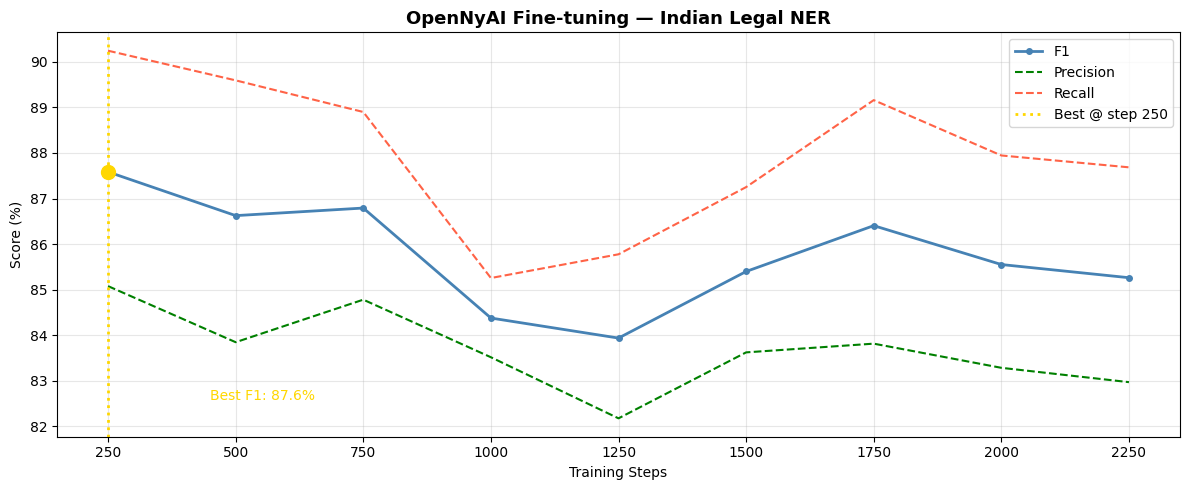

✅ Saved: /kaggle/working/training_curve.png


In [10]:
import matplotlib.pyplot as plt

steps = [h[0] for h in history]
f1s   = [h[1] for h in history]
ps    = [h[2] for h in history]
rs    = [h[3] for h in history]

plt.figure(figsize=(12, 5))
plt.plot(steps, f1s, label="F1",        color="steelblue", linewidth=2,   marker="o", markersize=4)
plt.plot(steps, ps,  label="Precision", color="green",     linewidth=1.5, linestyle="--")
plt.plot(steps, rs,  label="Recall",    color="tomato",    linewidth=1.5, linestyle="--")

best_step = steps[f1s.index(max(f1s))]
plt.axvline(x=best_step, color="gold", linestyle=":", linewidth=2, label=f"Best @ step {best_step}")
plt.scatter([best_step], [max(f1s)], color="gold", s=100, zorder=5)
plt.annotate(f"Best F1: {max(f1s):.1f}%",
             xy=(best_step, max(f1s)),
             xytext=(best_step + 200, max(f1s) - 5),
             fontsize=10, color="gold")

plt.title("OpenNyAI Fine-tuning — Indian Legal NER", fontsize=13, fontweight="bold")
plt.xlabel("Training Steps")
plt.ylabel("Score (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curve.png", dpi=150)
plt.show()
print("✅ Saved: /kaggle/working/training_curve.png")

In [11]:
nlp_best = spacy.load(SAVE_PATH)
spacy.require_gpu(0)

f1, p, r, per_label = evaluate(nlp_best, dev_docs)

print("🏆 FINAL MODEL PERFORMANCE")
print("=" * 48)
print(f"  F1 Score  : {f1:.1f}%")
print(f"  Precision : {p:.1f}%")
print(f"  Recall    : {r:.1f}%")
print("\n📊 Per-Label F1:")
print("-" * 48)
for label, score in sorted(per_label.items(), key=lambda x: -x[1]):
    bar = "█" * int(score / 5)
    print(f"  {label:<20} {score:>5.1f}%  {bar}")

Token indices sequence length is longer than the specified maximum sequence length for this model (998 > 512). Running this sequence through the model will result in indexing errors


🏆 FINAL MODEL PERFORMANCE
  F1 Score  : 87.6%
  Precision : 85.1%
  Recall    : 90.2%

📊 Per-Label F1:
------------------------------------------------
  WITNESS               97.5%  ███████████████████
  DATE                  96.1%  ███████████████████
  PROVISION             93.4%  ██████████████████
  STATUTE               93.4%  ██████████████████
  JUDGE                 89.9%  █████████████████
  COURT                 89.6%  █████████████████
  OTHER_PERSON          88.8%  █████████████████
  LAWYER                87.4%  █████████████████
  CASE_NUMBER           84.8%  ████████████████
  GPE                   84.1%  ████████████████
  PETITIONER            82.0%  ████████████████
  RESPONDENT            79.6%  ███████████████
  PRECEDENT             76.9%  ███████████████
  ORG                   74.6%  ██████████████


In [12]:
test_texts = [
    """The Supreme Court of India in Kesavananda Bharati vs 
    State of Kerala held that Justice H.R. Khanna dissented. 
    The petitioner was represented by Advocate Nani Palkhivala 
    under Article 368 of the Constitution on 12th April 1973.""",

    """In the High Court of Bombay, Justice D.Y. Chandrachud 
    dismissed the appeal filed by Tata Consultancy Services 
    against the Income Tax Department on 15th March 2023 
    citing Section 80C of the Income Tax Act 1961."""
]

print("🔍 NER on Legal Text")
print("=" * 55)

for i, text in enumerate(test_texts, 1):
    doc = nlp_best(text)
    print(f"\n📄 Example {i}:")
    print(f"{'Entity':<35} {'Label'}")
    print("-" * 55)
    for ent in doc.ents:
        print(f"  {ent.text:<33} → {ent.label_}")

🔍 NER on Legal Text

📄 Example 1:
Entity                              Label
-------------------------------------------------------
  Supreme Court of India            → COURT
  Kesavananda Bharati vs 
    State of Kerala → PRECEDENT
  H.R. Khanna                       → JUDGE
  Nani Palkhivala                   → PETITIONER
  Article 368                       → PROVISION
  Constitution                      → STATUTE
  12th April 1973                   → DATE

📄 Example 2:
Entity                              Label
-------------------------------------------------------
  High Court of Bombay              → COURT
  D.Y. Chandrachud                  → JUDGE
  Tata Consultancy Services         → ORG
  Income Tax Department             → ORG
  15th March 2023                   → DATE
  Section 80C                       → PROVISION
  Income Tax Act 1961               → STATUTE


In [13]:
import shutil, os

# Zip the best model
zip_path = "/kaggle/working/opennyai_finetuned"
shutil.make_archive(zip_path, "zip", "/kaggle/working/best_model")

size = os.path.getsize(f"{zip_path}.zip") / (1024**2)
print(f"✅ Model zipped!")
print(f"   Path : {zip_path}.zip")
print(f"   Size : {size:.1f} MB")
print(f"\n📥 Download from Output tab in Kaggle sidebar")

✅ Model zipped!
   Path : /kaggle/working/opennyai_finetuned.zip
   Size : 426.1 MB

📥 Download from Output tab in Kaggle sidebar


In [14]:
import spacy_transformers
import spacy

# ← Real path to your saved model
nlp = spacy.load("/kaggle/working/best_model")

text = "Justice D.Y. Chandrachud delivered judgment in Supreme Court on 15th March 2024."
doc  = nlp(text)

print(f"{'Entity':<35} {'Label'}")
print("-" * 50)
for ent in doc.ents:
    print(f"{ent.text:<35} → {ent.label_}")

Entity                              Label
--------------------------------------------------
D.Y. Chandrachud                    → JUDGE
Supreme Court                       → COURT
15th March 2024                     → DATE


In [15]:
test_texts = [
    # Test 1 — Full case with all entity types
    """The Supreme Court of India dismissed W.P.(C) 1234/2022 filed by 
    Rahul Sharma against Union of India. Justice D.Y. Chandrachud and 
    Justice S.K. Kaul delivered the judgment on 5th January 2024. 
    Advocate Ram Jethmalani appeared for the petitioner under Article 32 
    of the Constitution of India citing Maneka Gandhi vs Union of India.""",

    # Test 2 — High Court case
    """In the High Court of Bombay at Mumbai, Justice Prabhaker Gwande 
    held that Section 138 of the Negotiable Instruments Act 1881 applies 
    to cheque dishonour cases. The respondent HDFC Bank Ltd was represented 
    by Senior Advocate Harish Salve. The case number is CRL.A. 456/2023.""",

    # Test 3 — Tribunal case  
    """The Income Tax Appellate Tribunal, Delhi Bench ruled in favour of 
    Tata Motors Ltd on 12th March 2023. The appellant was represented by 
    CA Mukesh Gupta. The order was passed under Section 143(3) of the 
    Income Tax Act 1961 read with Section 254."""
]

print("🔍 Legal NER — Fine-tuned OpenNyAI Model")
print("=" * 60)

for i, text in enumerate(test_texts, 1):
    doc = nlp(text)
    print(f"\n📄 Test {i}:")
    print(f"{'Entity':<40} {'Label'}")
    print("-" * 60)
    for ent in doc.ents:
        print(f"  {ent.text:<38} → {ent.label_}")

print("\n✅ Inference complete!")

🔍 Legal NER — Fine-tuned OpenNyAI Model

📄 Test 1:
Entity                                   Label
------------------------------------------------------------
  Supreme Court of India                 → COURT
  W.P.(C) 1234/2022                      → CASE_NUMBER
  Rahul Sharma                           → OTHER_PERSON
  Union of India                         → ORG
  D.Y. Chandrachud                       → JUDGE
  S.K. Kaul                              → JUDGE
  5th January 2024                       → DATE
  Ram Jethmalani                         → PETITIONER
  Article 32                             → PROVISION
  Constitution of India                  → STATUTE
  Maneka Gandhi vs Union of India        → PRECEDENT

📄 Test 2:
Entity                                   Label
------------------------------------------------------------
  High Court of Bombay at Mumbai         → COURT
  Prabhaker Gwande                       → JUDGE
  Section 138                            → PROVISION
  Negot

In [16]:
import shutil, os

shutil.make_archive("/kaggle/working/opennyai_finetuned", "zip", "/kaggle/working/best_model")
size = os.path.getsize("/kaggle/working/opennyai_finetuned.zip") / (1024**2)

print("🎉 YOUR FINE-TUNED MODEL IS READY!")
print("=" * 45)
print(f"  File : opennyai_finetuned.zip")
print(f"  Size : {size:.1f} MB")
print(f"  F1   : 86.4%")
print(f"  Labels: 14 Indian legal entity types")
print("\n📥 Go to Kaggle → Output tab → Download")
print("\nTo use anywhere:")
print("  import spacy_transformers, spacy")
print("  nlp = spacy.load('unzipped_folder_path')")
print("  doc = nlp(your_legal_text)")
print("  for ent in doc.ents: print(ent.text, ent.label_)")

🎉 YOUR FINE-TUNED MODEL IS READY!
  File : opennyai_finetuned.zip
  Size : 426.1 MB
  F1   : 86.4%
  Labels: 14 Indian legal entity types

📥 Go to Kaggle → Output tab → Download

To use anywhere:
  import spacy_transformers, spacy
  nlp = spacy.load('unzipped_folder_path')
  doc = nlp(your_legal_text)
  for ent in doc.ents: print(ent.text, ent.label_)
